In [ ]:
!pip install sdv pandas numpy scikit-learn scipy matplotlib seaborn --quiet
!pip install torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 130.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.2 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import json, time, os, pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, roc_auc_score
)
from sklearn.neighbors import NearestNeighbors

from scipy.stats import ks_2samp, wasserstein_distance
from scipy import stats

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.sampling import Condition


plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='muted')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports successful')

All imports successful


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
output_path = '/content/drive/MyDrive/800epoc/'
DATA_PATH = Path('/content/drive/MyDrive/Dataset')

def load_all_cicids2017(data_path: Path) -> pd.DataFrame:
    csv_files = sorted(data_path.glob('*.csv'))
    print(f'Found {len(csv_files)} files:')
    dfs = []
    for f in csv_files:
        size = f.stat().st_size / 1024 / 1024
        print(f'  Loading {f.name} ({size:.1f} MB)...')
        df_temp = pd.read_csv(f, low_memory=False)
        df_temp.columns = df_temp.columns.str.strip()
        print(f'    → {len(df_temp):,} rows | {df_temp.shape[1]} cols')
        dfs.append(df_temp)
    df = pd.concat(dfs, ignore_index=True)
    df.columns = df.columns.str.strip()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip()
    return df

df_raw = load_all_cicids2017(DATA_PATH)
print(f'\nTotal rows    : {len(df_raw):,}')
print(f'Total columns : {df_raw.shape[1]}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 5 files:
  Loading Friday-WorkingHours.csv (269.5 MB)...
    → 547,915 rows | 84 cols
  Loading Monday-WorkingHours.csv (198.6 MB)...
    → 371,749 rows | 84 cols
  Loading Thursday-WorkingHours.csv (179.0 MB)...
    → 362,368 rows | 84 cols
  Loading Tuesday-WorkingHours.csv (170.2 MB)...
    → 322,003 rows | 84 cols
  Loading Wednesday-WorkingHours.csv (278.0 MB)...
    → 496,779 rows | 84 cols

Total rows    : 2,100,814
Total columns : 84


In [ ]:
LABEL_COL = 'Label'

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.strip()
    drop_keywords = ['flow id', 'source ip', 'src ip',
                     'destination ip', 'dst ip', 'timestamp', 'external ip']
    cols_to_drop = [
        c for c in df.columns
        if any(kw in c.lower() for kw in drop_keywords) and c != 'Label'
    ]
    df = df.drop(columns=cols_to_drop, errors='ignore')
    X = df.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    for col in X.columns:
        X[col] = X[col].clip(upper=X[col].quantile(0.995))
    X = X.clip(lower=0)
    out = X.copy()
    out['Label'] = df['Label'].str.strip().values
    return out

def merge_labels(df: pd.DataFrame, label_col: str = 'Label') -> pd.DataFrame:
    """Merge attempted variants and remove ultra-rare classes."""
    df = df.copy()
    label_map = {
        # Web attacks
        'Web Attack - Brute Force':           'Web-Based_Attacks',
        'Web Attack - Brute Force - Attempted':'Web-Based_Attacks',
        'Web Attack - XSS':                   'Web-Based_Attacks',
        'Web Attack - XSS - Attempted':       'Web-Based_Attacks',
        'Web Attack - Sql Injection':         'Web-Based_Attacks',
        'Bot':                                'Web-Based_Attacks',
        'Bot - Attempted':                    'Web-Based_Attacks',
        # DoS slow
        'DoS slowloris':                      'DoS_Slow',
        'DoS slowloris - Attempted':          'DoS_Slow',
        'DoS Slowhttptest':                   'DoS_Slow',
        'DoS Slowhttptest - Attempted':       'DoS_Slow',
        # Credential
        'FTP-Patator':                        'Credential_Attacks',
        'FTP-Patator - Attempted':            'Credential_Attacks',
        'SSH-Patator':                        'Credential_Attacks',
        'SSH-Patator - Attempted':            'Credential_Attacks',
        # DoS variants
        'DoS Hulk':                           'DoS_Hulk',
        'DoS Hulk - Attempted':               'DoS_Hulk',
        'DoS GoldenEye':                      'DoS_GoldenEye',
        'DoS GoldenEye - Attempted':          'DoS_GoldenEye',
        # Remove ultra-rare
        'Infiltration':                       'REMOVE',
        'Infiltration - Attempted':           'REMOVE',
        'Heartbleed':                         'REMOVE',
    }
    df[label_col] = df[label_col].replace(label_map)
    df = df[df[label_col] != 'REMOVE'].reset_index(drop=True)
    return df

df = preprocess(df_raw)
df = merge_labels(df, LABEL_COL)
LABEL_COL    = 'Label'
FEATURE_COLS = [c for c in df.columns if c != LABEL_COL]

print('Class distribution:')
print(df[LABEL_COL].value_counts())
print(f'\nFeatures: {len(FEATURE_COLS)}')



Class distribution:
Label
BENIGN                1657693
PortScan               159151
DoS_Hulk               159062
DDoS                    95123
DoS_Slow                10843
DoS_GoldenEye            7647
Credential_Attacks       6972
Web-Based_Attacks        4264
Name: count, dtype: int64

Features: 79


In [ ]:
CLASS_CAPS = {
    'BENIGN':             50_000,
    'DoS_Hulk':           20_000,
    'PortScan':           15_000,
    'DDoS':               10_000,
    'DoS_GoldenEye':       5_000,
    'DoS_Slow':            5_000,
    'Credential_Attacks':  3_000,
    'Web-Based_Attacks':   3_000,
}
#CLASS_CAPS = {}
DEFAULT_CAP = 2000
MAX_TOTAL = 500_000
df_full = df.copy()
if len(df_full) > MAX_TOTAL:
    df_full, _ = train_test_split(
        df_full, train_size=MAX_TOTAL,
        stratify=df_full[LABEL_COL], random_state=RANDOM_STATE
    )

df_train_ctgan = (
    df_full
    .groupby(LABEL_COL, group_keys=False)
    .apply(lambda x: x.sample(
        min(len(x), CLASS_CAPS.get(x.name, DEFAULT_CAP)),
        random_state=RANDOM_STATE
    ))
    .reset_index(drop=True)
)
print(df_train_ctgan[LABEL_COL].value_counts())
df_train_ctgan.to_csv('cicids2017_train.csv', index=False)
print('Saved → cicids2017_train.csv')

Label
BENIGN                50000
DoS_Hulk              20000
PortScan              15000
DDoS                  10000
DoS_Slow               2581
DoS_GoldenEye          1820
Credential_Attacks     1659
Web-Based_Attacks      1015
Name: count, dtype: int64
Saved → cicids2017_train.csv


In [ ]:
#Log1p Transform Skewed Features
def log_transform_skewed(
    df: pd.DataFrame,
    feature_cols: list,
    skew_threshold: float = 2.0
):
    df = df.copy()
    skewness = df[feature_cols].skew().abs()
    log_cols  = skewness[skewness > skew_threshold].index.tolist()
    for col in log_cols:
        df[col] = np.log1p(df[col].clip(lower=0))
    print(f'Log-transformed {len(log_cols)}/{len(feature_cols)} features '
          f'(skew > {skew_threshold})')
    return df, log_cols

def inverse_log_transform(df: pd.DataFrame, log_cols: list) -> pd.DataFrame:
    df = df.copy()
    for col in log_cols:
        if col in df.columns:
            df[col] = np.expm1(df[col]).clip(lower=0)
    return df

df_train_transformed, LOG_COLS = log_transform_skewed(df_train_ctgan, FEATURE_COLS)

Log-transformed 52/79 features (skew > 2.0)


In [ ]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_train_transformed)

CTGAN_CONFIG = dict(
    epochs              = 600,
    batch_size          = 1000,
    generator_dim       = (256, 256, 256),
    discriminator_dim   = (256, 256, 256),
    generator_lr        = 2e-4,
    discriminator_lr    = 2e-4,
    discriminator_steps = 1,
    pac                 = 10,
    verbose             = True,
    cuda                = True,
    log_frequency = True
)
print('CTGAN Configuration:')
for config, value in CTGAN_CONFIG.items():
    print(f'  {config}: {value}')

ctgan = CTGANSynthesizer(metadata, **CTGAN_CONFIG)

print('\nTraining CTGAN on log-transformed data...')
print('This may take 20–60 minutes depending on hardware.\n')

t0 = time.time()
ctgan.fit(df_train_transformed)
elapsed = time.time() - t0
print(f'\n Training completed in {elapsed/60:.1f} minutes')

with open(output_path +'ctgan_cicids2017.pkl', 'wb') as f:
    pickle.dump(ctgan, f)
print('Model saved → ctgan_cicids2017.pkl')

CTGAN Configuration:
  epochs: 600
  batch_size: 1000
  generator_dim: (256, 256, 256)
  discriminator_dim: (256, 256, 256)
  generator_lr: 0.0002
  discriminator_lr: 0.0002
  discriminator_steps: 1
  pac: 10
  verbose: True
  cuda: True
  log_frequency: True

Training CTGAN on log-transformed data...
This may take 20–60 minutes depending on hardware.



Gen. (-00.42) | Discrim. (-00.41): 100%|██████████| 600/600 [1:36:48<00:00,  9.68s/it]



 Training completed in 111.6 minutes
Model saved → ctgan_cicids2017.pkl


In [ ]:
real_counts   = df_train_ctgan[LABEL_COL].value_counts()
SAMPLE_COUNTS = real_counts.to_dict()

print('Sampling synthetic data per class:')
synth_dfs = []
for cls, n in SAMPLE_COUNTS.items():
    print(f'  {cls:<30} → {n:,} samples')
    condition = Condition(num_rows=n, column_values={LABEL_COL: cls})
    try:
        df_cls = ctgan.sample_from_conditions([condition])
        synth_dfs.append(df_cls)
    except Exception as e:
        print(f'    Failed: {e}')

df_synthetic_transformed = pd.concat(synth_dfs, ignore_index=True)

# Inverse transform back to original scale
df_synthetic = inverse_log_transform(df_synthetic_transformed, LOG_COLS)

# Clip to valid range
for col in FEATURE_COLS:
    if col in df_synthetic.columns:
        df_synthetic[col] = df_synthetic[col].clip(lower=0)

print(f'\nSynthetic data shape: {df_synthetic.shape}')
print('\nSynthetic class distribution:')
print(df_synthetic[LABEL_COL].value_counts())

real_cls   = set(df_train_ctgan[LABEL_COL].unique())
synth_cls  = set(df_synthetic[LABEL_COL].unique())
missing    = real_cls - synth_cls
print(f'\nMissing classes: {missing or "None "}')

df_synthetic.to_csv(output_path + 'cicids2017_synthetic.csv', index=False)
print('Saved → cicids2017_synthetic.csv')

Sampling synthetic data per class:
  BENIGN                         → 50,000 samples


Sampling conditions: 100%|██████████| 50000/50000 [00:12<00:00, 3934.48it/s]


  DoS_Hulk                       → 20,000 samples


Sampling conditions: 100%|██████████| 20000/20000 [00:11<00:00, 1783.88it/s]


  PortScan                       → 15,000 samples


...

  Credential_Attacks             → 1,659 samples


Sampling conditions: 100%|██████████| 1659/1659 [00:09<00:00, 168.54it/s]


  Web-Based_Attacks              → 1,015 samples


Sampling conditions: 100%|██████████| 1015/1015 [00:06<00:00, 146.63it/s]



Synthetic data shape: (102075, 80)

Synthetic class distribution:
Label
BENIGN                50000
DoS_Hulk              20000
PortScan              15000
DDoS                  10000
DoS_Slow               2581
DoS_GoldenEye          1820
Credential_Attacks     1659
Web-Based_Attacks      1015
Name: count, dtype: int64

Missing classes: None 
Saved → cicids2017_synthetic.csv


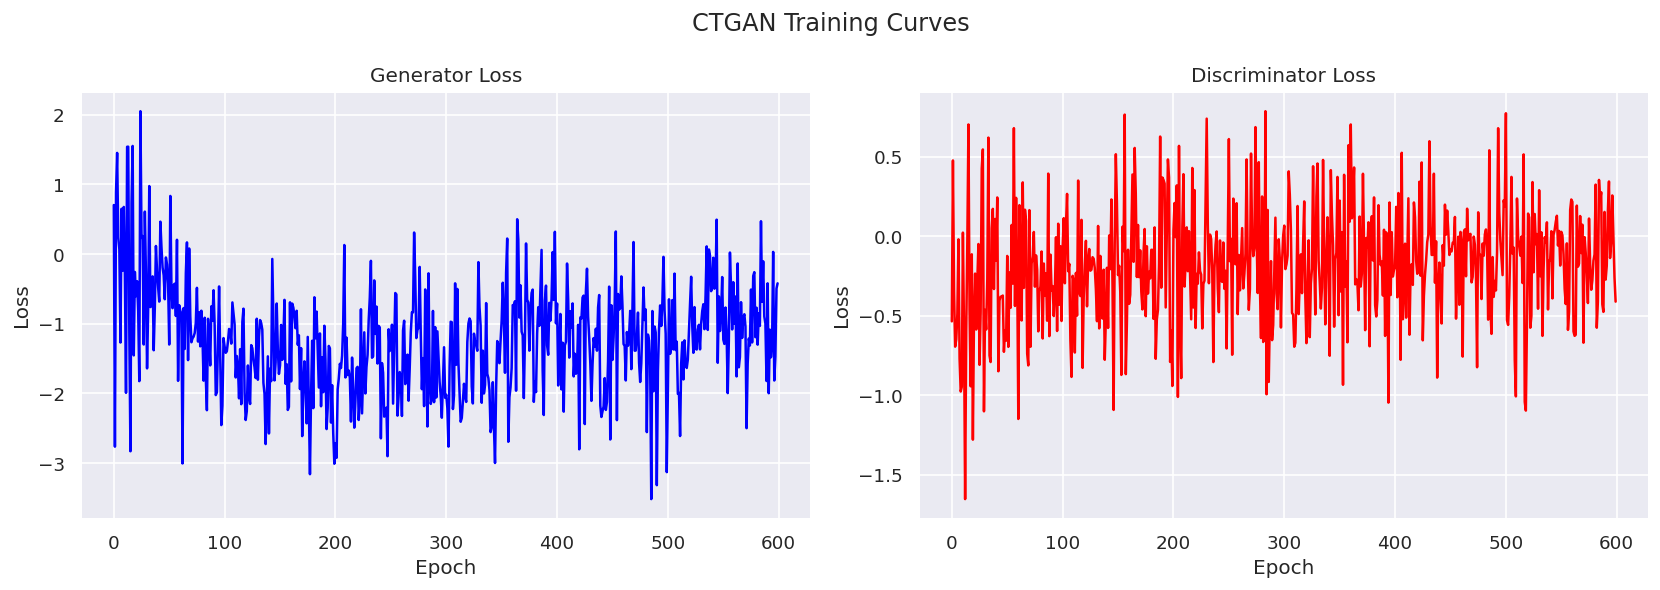

In [ ]:
loss_df = ctgan.get_loss_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_df['Epoch'], loss_df['Generator Loss'], color='blue')
axes[0].set_title('Generator Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(loss_df['Epoch'], loss_df['Discriminator Loss'], color='red')
axes[1].set_title('Discriminator Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.suptitle('CTGAN Training Curves')
plt.tight_layout()
plt.savefig(output_path +'protocol_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

from sdmetrics.single_column import KSComplement
import pandas as pd
import numpy as np

def evaluate_ks_complement(df_real: pd.DataFrame, df_synth: pd.DataFrame,
                            feature_cols: list) -> pd.DataFrame:
    results = []
    for col in feature_cols:
        if col not in df_synth.columns:
            continue
        try:
            score = KSComplement.compute(
                real_data      = df_real[col].dropna(),
                synthetic_data = df_synth[col].dropna(),
            )
        except Exception:
            score = 0.0
        results.append({
            'Feature':    col,
            'Score':      round(score, 6),
            'KS Stat':    round(1 - score, 6),
            'Good':       score > 0.7,
        })
    return pd.DataFrame(results).sort_values('Score')


def evaluate_label_distribution(df_real: pd.DataFrame, df_synth: pd.DataFrame,
                                  label_col: str) -> dict:

    real_dist  = df_real[label_col].value_counts(normalize=True)
    synth_dist = df_synth[label_col].value_counts(normalize=True)
    all_cls    = sorted(set(real_dist.index) | set(synth_dist.index))
    r_arr      = np.array([real_dist.get(c, 0) for c in all_cls])
    s_arr      = np.array([synth_dist.get(c, 0) for c in all_cls])
    tv_dist    = 0.5 * np.sum(np.abs(r_arr - s_arr))
    score      = round(1 - tv_dist, 6)
    return {
        'score':      score,
        'similar':    score > 0.7,
        'real_dist':  real_dist,
        'synth_dist': synth_dist,
    }

EVAL_REAL = df_train_ctgan.copy()

print('=' * 60)
print('📊 COLUMN SHAPES — KSComplement (SDV CTGAN metric)')
print('=' * 60)
print(f'   Real      : df_train ({len(EVAL_REAL):,} rows)')
print(f'   Synthetic : df_synthetic ({len(df_synthetic):,} rows)')

ks_results = evaluate_ks_complement(EVAL_REAL, df_synthetic, FEATURE_COLS)

n_good    = ks_results['Good'].sum()
n_total   = len(ks_results)
mean_score = ks_results['Score'].mean()

print(f'\nColumn Shapes Score      : {mean_score*100:.2f}%')
print(f'Features scoring > 0.7   : {n_good}/{n_total} ({n_good/n_total*100:.1f}%)')
print(f'Mean KSComplement        : {mean_score:.4f}')
print(f'Mean KS Statistic        : {1 - mean_score:.4f}')

print('\nTop 10 most similar features:')
print(ks_results.tail(10)[['Feature', 'Score', 'KS Stat', 'Good']].to_string(index=False))

print('\nTop 10 least similar features:')
print(ks_results.head(10)[['Feature', 'Score', 'KS Stat', 'Good']].to_string(index=False))

# ── Run Label Distribution ────────────────────────────────────────
print('\n' + '=' * 60)
print('LABEL DISTRIBUTION — TV Complement (SDV metric)')
print('=' * 60)

label_result = evaluate_label_distribution(EVAL_REAL, df_synthetic, LABEL_COL)

print(f'Label Distribution Score : {label_result["score"]*100:.2f}%')
print(f'Similar (score > 0.7)    : {label_result["similar"]}')
print()
print(f'{"Class":<25} {"Real %":>8} {"Synth %":>9} {"Diff":>8}')
print('-' * 55)
all_cls = sorted(set(label_result['real_dist'].index) |
                  set(label_result['synth_dist'].index))
for cls in all_cls:
    r    = label_result['real_dist'].get(cls, 0) * 100
    s    = label_result['synth_dist'].get(cls, 0) * 100
    diff = s - r
    flag = '✅' if abs(diff) < 5 else '⚠️'
    print(f'{flag} {cls:<23} {r:>7.1f}%  {s:>7.1f}%  {diff:>+7.1f}%')

# ── Summary ───────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('📊 SUMMARY')
print('=' * 60)
print(f'Column Shapes Score      : {mean_score*100:.2f}%')
print(f'Label Distribution Score : {label_result["score"]*100:.2f}%')
overall = (mean_score + label_result['score']) / 2
print(f'Overall                  : {overall*100:.2f}%')
flag = '✅' if overall > 0.85 else '⚠️' if overall > 0.70 else '❌'
print(f'Rating                   : {flag} {"Excellent" if overall>0.85 else "Good" if overall>0.70 else "Fair"}')

📊 COLUMN SHAPES — KSComplement (SDV CTGAN metric)
   Real      : df_train (102,075 rows)
   Synthetic : df_synthetic (102,075 rows)

Column Shapes Score      : 80.77%
Features scoring > 0.7   : 62/79 (78.5%)
Mean KSComplement        : 0.8077
Mean KS Statistic        : 0.1923

Top 10 most similar features:
            Feature    Score  KS Stat  Good
           Protocol 0.967279 0.032721  True
  Packet Length Min 0.968014 0.031986  True
   Fwd Seg Size Min 0.974715 0.025285  True
     SYN Flag Count 0.975087 0.024913  True
     CWR Flag Count 1.000000 0.000000  True
     ECE Flag Count 1.000000 0.000000  True
      Bwd URG Flags 1.000000 0.000000  True
      Fwd URG Flags 1.000000 0.000000  True
     URG Flag Count 1.000000 0.000000  True
Subflow Bwd Packets 1.000000 0.000000  True

Top 10 least similar features:
            Feature    Score  KS Stat  Good
  Fwd Bulk Rate Avg 0.225971 0.774029 False
Fwd Packet/Bulk Avg 0.282116 0.717884 False
         Active Min 0.398462 0.601538 False
 

📊  CORRELATION STRUCTURE — vs df_full
  Mean Abs Correlation Error: 0.0619
  Max Abs Correlation Error : 0.3798
 Excellent (MAE < 0.10)


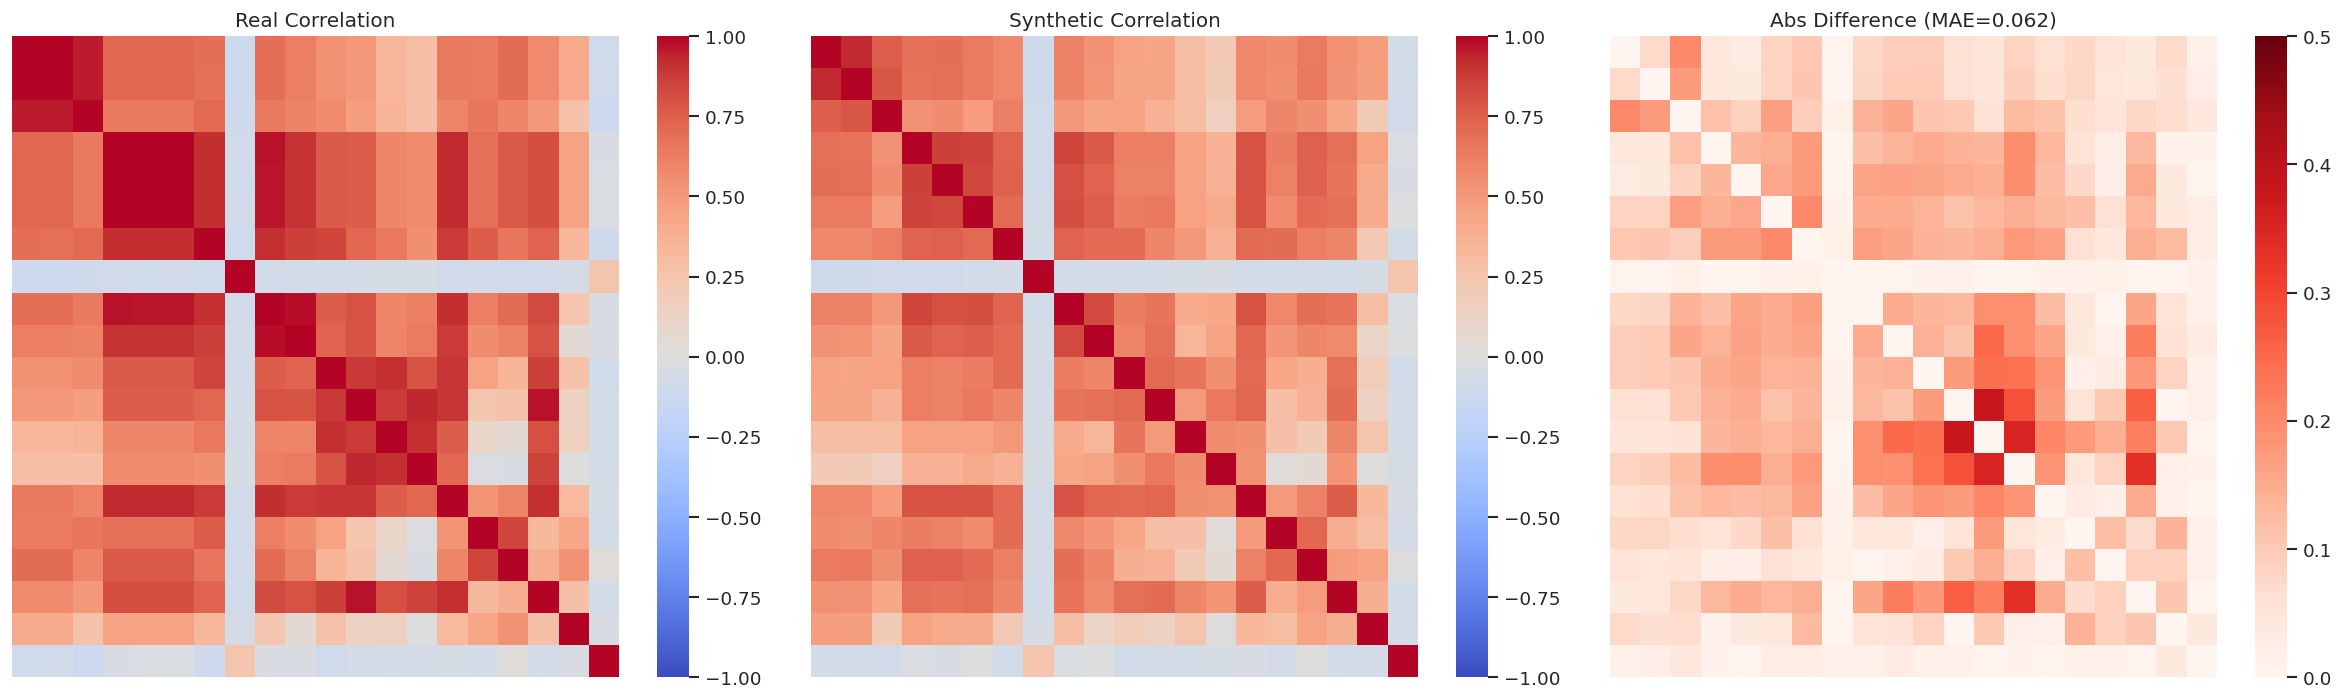

In [ ]:
def evaluate_correlation(
    df_real: pd.DataFrame, df_synth: pd.DataFrame,
    feature_cols: list, top_n: int = 30
) -> dict:
    cols      = [c for c in feature_cols if c in df_synth.columns]
    top_feats = df_real[cols].var().nlargest(top_n).index.tolist()
    corr_real  = df_real[top_feats].corr()
    corr_synth = df_synth[top_feats].corr()
    corr_diff  = (corr_real - corr_synth).abs()
    idx        = np.triu_indices_from(corr_diff.values, k=1)
    return {
        'corr_real':       corr_real,
        'corr_synth':      corr_synth,
        'corr_diff':       corr_diff,
        'mean_abs_error':  corr_diff.values[idx].mean(),
        'max_abs_error':   corr_diff.values[idx].max(),
        'feature_subset':  top_feats,
    }

corr_eval = evaluate_correlation(EVAL_REAL, df_synthetic, FEATURE_COLS)
output_path = '/content/drive/MyDrive/1000epochrun/'
print('=' * 62)
print('📊  CORRELATION STRUCTURE — vs df_full')
print('=' * 62)
print(f'  Mean Abs Correlation Error: {corr_eval["mean_abs_error"]:.4f}')
print(f'  Max Abs Correlation Error : {corr_eval["max_abs_error"]:.4f}')

if   corr_eval['mean_abs_error'] < 0.10: print(' Excellent (MAE < 0.10)')
elif corr_eval['mean_abs_error'] < 0.20: print(' Good (MAE < 0.20)')
else:                                     print('  Fair ')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
subset = corr_eval['feature_subset'][:20]
sns.heatmap(corr_eval['corr_real'].loc[subset, subset],   ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, xticklabels=False, yticklabels=False)
sns.heatmap(corr_eval['corr_synth'].loc[subset, subset],  ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, xticklabels=False, yticklabels=False)
sns.heatmap(corr_eval['corr_diff'].loc[subset, subset],   ax=axes[2], cmap='Reds',     vmin=0,  vmax=0.5, xticklabels=False, yticklabels=False)
axes[0].set_title('Real Correlation')
axes[1].set_title('Synthetic Correlation')
axes[2].set_title(f'Abs Difference (MAE={corr_eval["mean_abs_error"]:.3f})')
plt.tight_layout()
plt.savefig(output_path +'eval_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
def evaluate_wasserstein(
    df_real: pd.DataFrame, df_synth: pd.DataFrame, feature_cols: list
) -> pd.DataFrame:
    results = []
    for col in feature_cols:
        if col not in df_synth.columns:
            continue
        r = df_real[col].dropna().values.astype(float)
        s = df_synth[col].dropna().values.astype(float)
        combined_min = min(r.min(), s.min())
        rng = max(r.max(), s.max()) - combined_min + 1e-9
        wd  = wasserstein_distance((r - combined_min) / rng, (s - combined_min) / rng)
        results.append({'Feature': col, 'Wasserstein': round(wd, 6)})
    return pd.DataFrame(results).sort_values('Wasserstein')

# CHANGE 5: compare against df_full
wd_results = evaluate_wasserstein(df_full, df_synthetic, FEATURE_COLS)

print('=' * 62)
print('📊  WASSERSTEIN DISTANCE (Normalized) — vs df_full')
print('=' * 62)
print(f'  Mean   : {wd_results["Wasserstein"].mean():.6f}')
print(f'  Median : {wd_results["Wasserstein"].median():.6f}')
print(f'  Max    : {wd_results["Wasserstein"].max():.6f}')
print('\nTop 10 worst:')
print(wd_results.tail(10).to_string(index=False))

📊  WASSERSTEIN DISTANCE (Normalized) — vs df_full
  Mean   : 0.033537
  Median : 0.012929
  Max    : 0.142052

Top 10 worst:
               Feature  Wasserstein
        SYN Flag Count     0.103341
        RST Flag Count     0.103440
      Fwd Seg Size Min     0.105572
  Bwd Segment Size Avg     0.108498
     Packet Length Std     0.110074
    Packet Length Mean     0.110497
Bwd Packet Length Mean     0.111745
     Subflow Bwd Bytes     0.126178
   Average Packet Size     0.131055
              Protocol     0.142052


In [ ]:
def run_tstr(
    df_synth: pd.DataFrame, df_real: pd.DataFrame,
    feature_cols: list, label_col: str, test_size: float = 0.3
) -> dict:
    le = LabelEncoder()
    le.fit(pd.concat([df_synth[label_col], df_real[label_col]]).unique())
    common = [c for c in feature_cols if c in df_synth.columns and c in df_real.columns]

    X_synth = df_synth[common].fillna(0).values
    y_synth = le.transform(df_synth[label_col])
    X_real  = df_real[common].fillna(0).values
    y_real  = le.transform(df_real[label_col])

    _, X_test, _, y_test = train_test_split(
        X_real, y_real, test_size=test_size, stratify=y_real, random_state=RANDOM_STATE
    )
    scaler      = StandardScaler()
    X_tr_sc     = scaler.fit_transform(X_synth)
    X_te_sc     = scaler.transform(X_test)

    clf = RandomForestClassifier(
        n_estimators=200, max_depth=15,
        n_jobs=1,                        # CHANGE 6: CPU safe
        random_state=RANDOM_STATE, class_weight='balanced'
    )
    clf.fit(X_tr_sc, y_synth)
    y_pred = clf.predict(X_te_sc)

    return {
        'accuracy':      accuracy_score(y_test, y_pred),
        'f1_macro':      f1_score(y_test, y_pred, average='macro',    zero_division=0),
        'f1_weighted':   f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall_macro':  recall_score(y_test, y_pred, average='macro',zero_division=0),
        'report':        classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0),
        'y_test': y_test, 'y_pred': y_pred, 'label_encoder': le,
        'feature_cols': common, 'scaler': scaler, 'clf': clf,
    }

print('=' * 62)
print('📊  TSTR — Train on Synthetic, Test on Real')
print('=' * 62)
tstr = run_tstr(df_synthetic, df_full, FEATURE_COLS, LABEL_COL)
print(f'  Accuracy   : {tstr["accuracy"]:.4f}')
print(f'  F1 Macro   : {tstr["f1_macro"]:.4f}')
print(f'  F1 Weighted: {tstr["f1_weighted"]:.4f}')
print(f'  Recall Mac : {tstr["recall_macro"]:.4f}')
print()
print(tstr['report'])

📊  TSTR — Train on Synthetic, Test on Real
  Accuracy   : 0.9782
  F1 Macro   : 0.8533
  F1 Weighted: 0.9813
  Recall Mac : 0.9556

                    precision    recall  f1-score   support

            BENIGN       1.00      0.98      0.99    118364
Credential_Attacks       0.92      0.99      0.96       498
              DDoS       1.00      1.00      1.00      6792
     DoS_GoldenEye       0.96      0.97      0.97       546
          DoS_Hulk       1.00      0.99      1.00     11357
          DoS_Slow       0.54      0.85      0.66       774
          PortScan       0.90      0.99      0.94     11364
 Web-Based_Attacks       0.19      0.87      0.32       305

          accuracy                           0.98    150000
         macro avg       0.81      0.96      0.85    150000
      weighted avg       0.99      0.98      0.98    150000



In [ ]:
def run_trts(
    df_real: pd.DataFrame, df_synth: pd.DataFrame,
    feature_cols: list, label_col: str, test_size: float = 0.3
) -> dict:
    le = LabelEncoder()
    le.fit(pd.concat([df_real[label_col], df_synth[label_col]]).unique())
    common = [c for c in feature_cols if c in df_synth.columns and c in df_real.columns]

    X_real  = df_real[common].fillna(0).values
    y_real  = le.transform(df_real[label_col])
    X_synth = df_synth[common].fillna(0).values
    y_synth = le.transform(df_synth[label_col])

    X_train, _, y_train, _ = train_test_split(
        X_real, y_real, test_size=test_size, stratify=y_real, random_state=RANDOM_STATE
    )
    scaler     = StandardScaler()
    X_tr_sc    = scaler.fit_transform(X_train)
    X_sy_sc    = scaler.transform(X_synth)

    clf = RandomForestClassifier(
        n_estimators=200, max_depth=15,
        n_jobs=1,                        # CHANGE 6
        random_state=RANDOM_STATE, class_weight='balanced'
    )
    clf.fit(X_tr_sc, y_train)
    y_pred = clf.predict(X_sy_sc)

    return {
        'accuracy':     accuracy_score(y_synth, y_pred),
        'f1_macro':     f1_score(y_synth, y_pred, average='macro',    zero_division=0),
        'f1_weighted':  f1_score(y_synth, y_pred, average='weighted', zero_division=0),
        'recall_macro': recall_score(y_synth, y_pred, average='macro',zero_division=0),
        'report':       classification_report(y_synth, y_pred, target_names=le.classes_, zero_division=0),
        'y_test': y_synth, 'y_pred': y_pred, 'label_encoder': le,
    }

print('=' * 62)
print('📊  TRTS — Train on Real, Test on Synthetic')
print('=' * 62)
trts = run_trts(df_full, df_synthetic, FEATURE_COLS, LABEL_COL)
print(f'  Accuracy   : {trts["accuracy"]:.4f}')
print(f'  F1 Macro   : {trts["f1_macro"]:.4f}')
print(f'  F1 Weighted: {trts["f1_weighted"]:.4f}')
print(f'  Recall Mac : {trts["recall_macro"]:.4f}')
print()
gap = abs(tstr['f1_macro'] - trts['f1_macro'])
print(f'  TSTR/TRTS F1 Gap: {gap:.4f} {"✅" if gap < 0.10 else "⚠️"}')
print()
print(trts['report'])

📊  TRTS — Train on Real, Test on Synthetic
  Accuracy   : 0.9264
  F1 Macro   : 0.7622
  F1 Weighted: 0.9190
  Recall Mac : 0.6940

  TSTR/TRTS F1 Gap: 0.0911 ✅

                    precision    recall  f1-score   support

            BENIGN       0.89      0.99      0.94     50000
Credential_Attacks       0.99      0.71      0.83      1659
              DDoS       0.96      0.94      0.95     10000
     DoS_GoldenEye       0.94      0.52      0.67      1820
          DoS_Hulk       0.98      0.91      0.94     20000
          DoS_Slow       0.98      0.30      0.46      2581
          PortScan       0.97      0.96      0.96     15000
 Web-Based_Attacks       0.75      0.22      0.34      1015

          accuracy                           0.93    102075
         macro avg       0.93      0.69      0.76    102075
      weighted avg       0.93      0.93      0.92    102075



In [ ]:
le          = tstr['label_encoder']
y_test      = tstr['y_test']
y_pred      = tstr['y_pred']
classes     = le.classes_
class_names = classes

recall_per_class = recall_score(
    y_test, y_pred, average=None, zero_division=0, labels=range(len(classes))
)

rows = []
for i, cls in enumerate(classes):
    recall = recall_per_class[i]
    rows.append({
        'Class':        cls,
        'Type':         'Benign' if cls.upper() == 'BENIGN' else 'Attack',
        'Recall':       round(recall, 4),
        'FNR':          round(1 - recall, 4),
        'Real Support': int((y_test == i).sum()),
    })

recall_df    = pd.DataFrame(rows).sort_values(['Type', 'Recall'], ascending=[False, True])
attack_stats = recall_df[recall_df['Type'] == 'Attack']
benign_stats = recall_df[recall_df['Type'] == 'Benign']

print('=' * 62)
print('📊  ATTACK RECALL & FNR (TSTR)')
print('=' * 62)
print('\nAttack Classes:')
print(attack_stats.to_string(index=False))
print('\nBenign:')
print(benign_stats.to_string(index=False))
print(f'\n  Mean Attack Recall : {attack_stats["Recall"].mean():.4f}')
print(f'  Min Attack Recall  : {attack_stats["Recall"].min():.4f}  ({attack_stats.loc[attack_stats["Recall"].idxmin(), "Class"]})')
print(f'  Mean Attack FNR    : {attack_stats["FNR"].mean():.4f}')

print('\n--- Full Classification Report ---')
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

📊  ATTACK RECALL & FNR (TSTR)

Attack Classes:
             Class   Type  Recall    FNR  Real Support
          DoS_Slow Attack  0.8514 0.1486           774
 Web-Based_Attacks Attack  0.8689 0.1311           305
     DoS_GoldenEye Attack  0.9707 0.0293           546
Credential_Attacks Attack  0.9920 0.0080           498
          PortScan Attack  0.9924 0.0076         11364
          DoS_Hulk Attack  0.9941 0.0059         11357
              DDoS Attack  0.9999 0.0001          6792

Benign:
 Class   Type  Recall    FNR  Real Support
BENIGN Benign  0.9752 0.0248        118364

  Mean Attack Recall : 0.9528
  Min Attack Recall  : 0.8514  (DoS_Slow)
  Mean Attack FNR    : 0.0472

--- Full Classification Report ---
                    precision    recall  f1-score   support

            BENIGN     0.9981    0.9752    0.9865    118364
Credential_Attacks     0.9234    0.9920    0.9564       498
              DDoS     0.9991    0.9999    0.9995      6792
     DoS_GoldenEye     0.9619    0.970

In [ ]:
def evaluate_mode_collapse(
    df_real: pd.DataFrame, df_synth: pd.DataFrame,
    label_col: str, feature_cols: list
) -> dict:
    real_cls  = set(df_real[label_col].unique())
    synth_cls = set(df_synth[label_col].unique())
    common_features = [c for c in feature_cols if c in df_synth.columns][:20]

    diversity = {}
    for cls in (real_cls & synth_cls):
        r = df_real[df_real[label_col]  == cls][common_features]
        s = df_synth[df_synth[label_col] == cls][common_features]
        if len(r) < 5 or len(s) < 5:
            continue
        r_std = r.std().mean()
        s_std = s.std().mean()
        ratio = s_std / (r_std + 1e-9)
        diversity[cls] = {
            'real_std': round(r_std, 4), 'synth_std': round(s_std, 4),
            'std_ratio': round(ratio, 4), 'collapsed': ratio < 0.3,
            'n_real': len(r), 'n_synth': len(s),
        }

    return {
        'class_coverage':    len(synth_cls) / len(real_cls),
        'missing_classes':   list(real_cls - synth_cls),
        'collapsed_classes': [c for c, v in diversity.items() if v['collapsed']],
        'diversity_per_class': diversity,
    }

mode_result = evaluate_mode_collapse(df_full, df_synthetic, LABEL_COL, FEATURE_COLS)

print('=' * 62)
print('📊  MODE COLLAPSE CHECK — vs df_full')
print('=' * 62)
print(f'  Class Coverage    : {mode_result["class_coverage"]:.1%}')
print(f'  Missing Classes   : {mode_result["missing_classes"] or "None ✅"}')
print(f'  Collapsed Classes : {mode_result["collapsed_classes"] or "None ✅"}')
print()
div_df = pd.DataFrame(mode_result['diversity_per_class']).T
if not div_df.empty:
    print(div_df[['n_real','n_synth','real_std','synth_std','std_ratio','collapsed']].to_string())

📊  MODE COLLAPSE CHECK — vs df_full
  Class Coverage    : 100.0%
  Missing Classes   : None ✅
  Collapsed Classes : None ✅

                    n_real n_synth      real_std     synth_std std_ratio collapsed
DDoS                 22640   10000   283126.6771   506976.6698    1.7906     False
Web-Based_Attacks     1015    1015   474409.4657   620305.9822    1.3075     False
PortScan             37880   15000    20230.2304   129839.4301    6.4181     False
DoS_Slow              2581    2581  3352038.2228  3033041.9398    0.9048     False
DoS_Hulk             37858   20000   345325.2183   515813.0856    1.4937     False
DoS_GoldenEye         1820    1820  2094317.6832  2232018.5004    1.0657     False
Credential_Attacks    1659    1659   109056.5534   347300.6896    3.1846     False
BENIGN              394547   50000  2211000.5051  2111850.9759    0.9552     False


📊 PRIVACY LEAKAGE — NEAR-DUPLICATE DETECTION
Mean NN Distance:        0.391242
Median NN Distance:      0.265080
Min NN Distance:         0.006438
Near-duplicates (d<0.01): 13 (0.26%)
Privacy Safe (<1%):      ✅ Yes


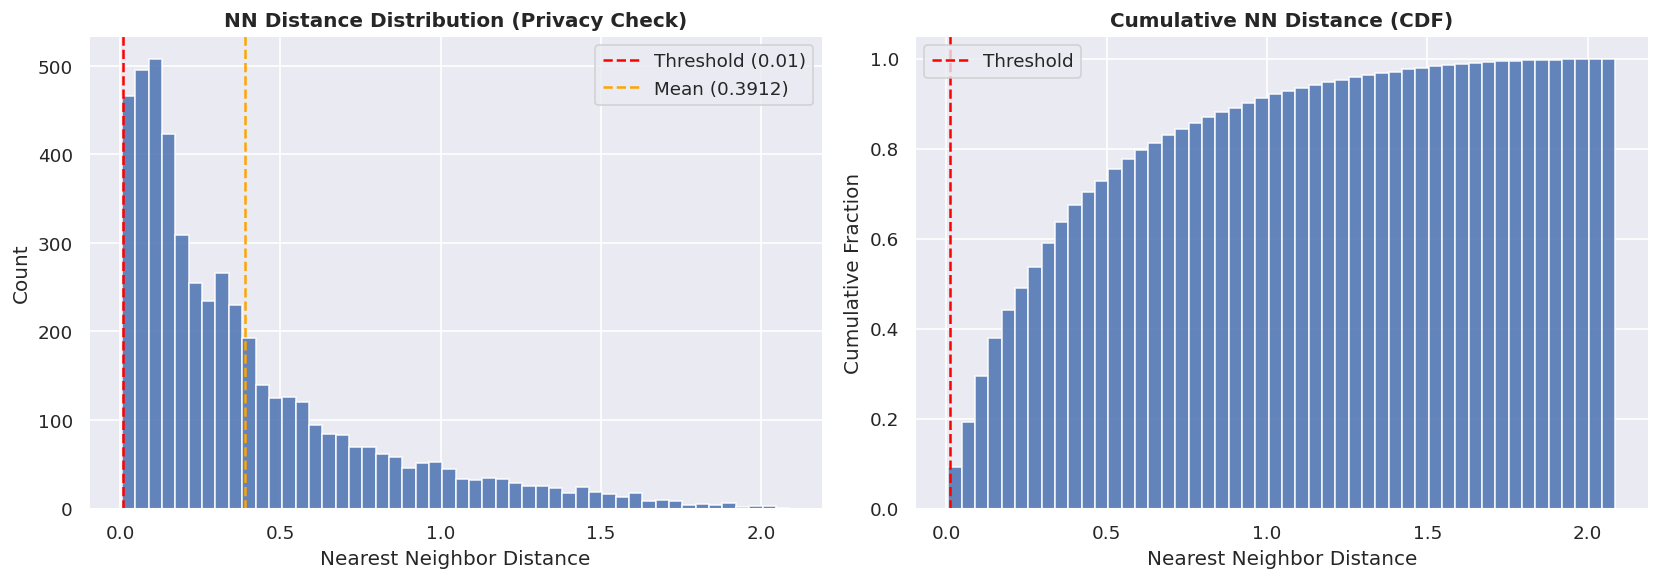

✅ Plot saved


In [ ]:
def evaluate_privacy_leakage(
    df_real: pd.DataFrame, df_synth: pd.DataFrame,
    feature_cols: list,
    n_sample: int = 5000,
    distance_threshold: float = 0.01
) -> dict:
    """
    Privacy leakage via Nearest Neighbor Distance Ratio (NNDR).

    For each synthetic sample, find its nearest real neighbor.
    If the distance is below threshold → potential memorization.

    Reference: Stadler et al. (2022) - Synthetic Data Anonymization
    """
    common_features = [c for c in feature_cols if c in df_synth.columns and c in df_real.columns]

    n_real = min(n_sample, len(df_real))
    n_synth = min(n_sample, len(df_synth))

    real_sample = df_real[common_features].sample(n=n_real, random_state=RANDOM_STATE).fillna(0).values.astype(float)
    synth_sample = df_synth[common_features].sample(n=n_synth, random_state=RANDOM_STATE).fillna(0).values.astype(float)

    # Normalize
    scaler = MinMaxScaler()
    real_scaled = scaler.fit_transform(real_sample)
    synth_scaled = scaler.transform(synth_sample)

    # Find nearest neighbor in real data for each synthetic sample
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
    nn.fit(real_scaled)
    distances, _ = nn.kneighbors(synth_scaled)

    min_distances = distances[:, 0]

    n_near_duplicates = (min_distances < distance_threshold).sum()
    near_duplicate_pct = n_near_duplicates / len(min_distances) * 100

    return {
        'min_distances': min_distances,
        'mean_nn_distance': min_distances.mean(),
        'median_nn_distance': np.median(min_distances),
        'min_nn_distance': min_distances.min(),
        'n_near_duplicates': n_near_duplicates,
        'near_duplicate_pct': near_duplicate_pct,
        'threshold': distance_threshold,
        'privacy_safe': near_duplicate_pct < 1.0  # <1% near-duplicates is safe
    }


print('=' * 60)
print('📊 PRIVACY LEAKAGE — NEAR-DUPLICATE DETECTION')
print('=' * 60)

privacy = evaluate_privacy_leakage(df_train_ctgan, df_synthetic, FEATURE_COLS)

print(f'Mean NN Distance:        {privacy["mean_nn_distance"]:.6f}')
print(f'Median NN Distance:      {privacy["median_nn_distance"]:.6f}')
print(f'Min NN Distance:         {privacy["min_nn_distance"]:.6f}')
print(f'Near-duplicates (d<{privacy["threshold"]}): {privacy["n_near_duplicates"]} ({privacy["near_duplicate_pct"]:.2f}%)')
print(f'Privacy Safe (<1%):      {"✅ Yes" if privacy["privacy_safe"] else "❌ No"}')

# Visualize distance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(privacy['min_distances'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(privacy['threshold'], color='red', linestyle='--',
           label=f'Threshold ({privacy["threshold"]})')
ax.axvline(privacy['mean_nn_distance'], color='orange', linestyle='--',
           label=f'Mean ({privacy["mean_nn_distance"]:.4f})')
ax.set_xlabel('Nearest Neighbor Distance')
ax.set_ylabel('Count')
ax.set_title('NN Distance Distribution (Privacy Check)', fontweight='bold')
ax.legend()

ax = axes[1]
ax.hist(privacy['min_distances'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.85, cumulative=True, density=True)
ax.axvline(privacy['threshold'], color='red', linestyle='--', label=f'Threshold')
ax.set_xlabel('Nearest Neighbor Distance')
ax.set_ylabel('Cumulative Fraction')
ax.set_title('Cumulative NN Distance (CDF)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(output_path + 'eval_privacy.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Plot saved')

In [ ]:
with open('/content/drive/MyDrive/1000epochrun/ctgan_cicids2017.pkl', 'rb') as f:
    loaded_ctgan = pickle.load(f)
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
#Log1p Transform Skewed Features
def log_transform_skewed(
    df: pd.DataFrame,
    feature_cols: list,
    skew_threshold: float = 2.0
):
    df = df.copy()
    skewness = df[feature_cols].skew().abs()
    log_cols  = skewness[skewness > skew_threshold].index.tolist()
    for col in log_cols:
        df[col] = np.log1p(df[col].clip(lower=0))
    print(f'Log-transformed {len(log_cols)}/{len(feature_cols)} features '
          f'(skew > {skew_threshold})')
    return df, log_cols

def inverse_log_transform(df: pd.DataFrame, log_cols: list) -> pd.DataFrame:
    df = df.copy()
    for col in log_cols:
        if col in df.columns:
            df[col] = np.expm1(df[col]).clip(lower=0)
    return df

df_train_transformed, LOG_COLS = log_transform_skewed(df_train_ctgan, FEATURE_COLS)

Log-transformed 52/79 features (skew > 2.0)


In [ ]:
df_synthetic =  loaded_ctgan.sample(len(df_train_transformed))
#



In [ ]:
# Inverse transform back to original scale
# Redefine inverse_log_transform to handle non-numeric columns
def inverse_log_transform(df: pd.DataFrame, log_cols: list) -> pd.DataFrame:
    df = df.copy()
    for col in log_cols:
        if col in df.columns:
            # Check if the column is numeric before attempting expm1
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = np.expm1(df[col]).clip(lower=0)
            else:
                print(f"Warning: Column '{col}' in synthetic data has dtype '{df[col].dtype}' and cannot be inverse log-transformed. Skipping this column.")
    return df

df_synthetic = inverse_log_transform(df_synthetic_transformed, LOG_COLS)

# Clip to valid range
for col in FEATURE_COLS:
    if col in df_synthetic.columns:
        df_synthetic[col] = df_synthetic[col].clip(lower=0)

print(f'\nSynthetic data shape: {df_synthetic.shape}')
print('\nSynthetic class distribution:')
print(df_synthetic[LABEL_COL].value_counts())

real_cls   = set(df_train_ctgan[LABEL_COL].unique())
synth_cls  = set(df_synthetic[LABEL_COL].unique())
missing    = real_cls - synth_cls
print(f'\nMissing classes: {missing or "None "}')

df_synthetic.to_csv('cicids2017new_synthetic.csv', index=False)
print('Saved → cicids2017_synthetic.csv')


Synthetic data shape: (102075, 80)

Synthetic class distribution:
Label
BENIGN                50000
DoS_Hulk              20000
PortScan              15000
DDoS                  10000
DoS_Slow               2581
DoS_GoldenEye          1820
Credential_Attacks     1659
Web-Based_Attacks      1015
Name: count, dtype: int64

Missing classes: None 
Saved → cicids2017_synthetic.csv


In [ ]:
from sdmetrics.reports.single_table import QualityReport

report = QualityReport()
report.generate(df_train_ctgan, df_synthetic,  metadata.to_dict())

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 80/80 [00:02<00:00, 37.83it/s]|
Column Shapes Score: 80.98%

(2/2) Evaluating Column Pair Trends: |██████████| 3160/3160 [01:08<00:00, 46.46it/s]|
Column Pair Trends Score: 93.48%

Overall Score (Average): 87.23%



In [ ]:
report.get_visualization(property_name='Column Shapes')
plt.show()